In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes new dataset.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Level
0,1,123.854532,70.552013,47.564623,140.225349,44.067900,0.205703,40.960570,0,Obese,Mid,Prediabetes
1,1,117.297774,71.079050,41.263556,111.154260,29.703077,1.136390,33.340828,0,Overweight,Adult,Prediabetes
2,2,110.176908,100.378619,29.175547,117.197124,28.162753,1.915921,42.772262,0,Overweight,Mid,Prediabetes
3,2,116.422941,95.603386,32.177355,143.376177,31.713198,2.046737,53.276358,1,Obese,Mid,Prediabetes
4,4,97.760847,77.837421,33.367973,121.180076,29.708066,0.585468,32.190160,1,Overweight,Adult,Normal


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               6000 non-null   int64  
 1   Glucose                   5400 non-null   float64
 2   BloodPressure             5400 non-null   float64
 3   SkinThickness             5400 non-null   float64
 4   Insulin                   5400 non-null   float64
 5   BMI                       5400 non-null   float64
 6   DiabetesPedigreeFunction  6000 non-null   float64
 7   Age                       6000 non-null   float64
 8   Outcome                   6000 non-null   int64  
 9   BMI_Category              6000 non-null   str    
 10  Age_Group                 6000 non-null   str    
 11  Glucose_Level             6000 non-null   str    
dtypes: float64(7), int64(2), str(3)
memory usage: 562.6 KB


In [4]:
df.shape


(6000, 12)

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'BMI_Category',
       'Age_Group', 'Glucose_Level'],
      dtype='str')

In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,6000.00000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,6000.000000,6000.000000,6000.000000
mean,2.03700,115.835214,83.825779,35.515809,135.953069,31.774559,1.298174,35.392750,0.500167
std,1.43677,11.739758,9.912827,6.837043,21.365675,5.841747,0.688374,11.161992,0.500042
min,0.00000,75.032013,50.593698,10.000000,61.840956,18.000000,0.100112,18.000000,0.000000
25%,1.00000,107.913429,77.130215,30.784689,121.719285,27.713900,0.719152,27.037625,0.000000
50%,2.00000,115.763613,83.784085,35.628496,135.844838,31.736218,1.290135,35.023442,1.000000
75%,3.00000,123.784172,90.573293,40.245514,150.184380,35.769599,1.890566,42.882272,1.000000
max,8.00000,159.083268,117.458364,59.394238,225.161865,50.000000,2.499855,80.000000,1.000000


In [6]:
df.isnull().sum()

Pregnancies                   0
Glucose                     600
BloodPressure               600
SkinThickness               600
Insulin                     600
BMI                         600
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
BMI_Category                  0
Age_Group                     0
Glucose_Level                 0
dtype: int64

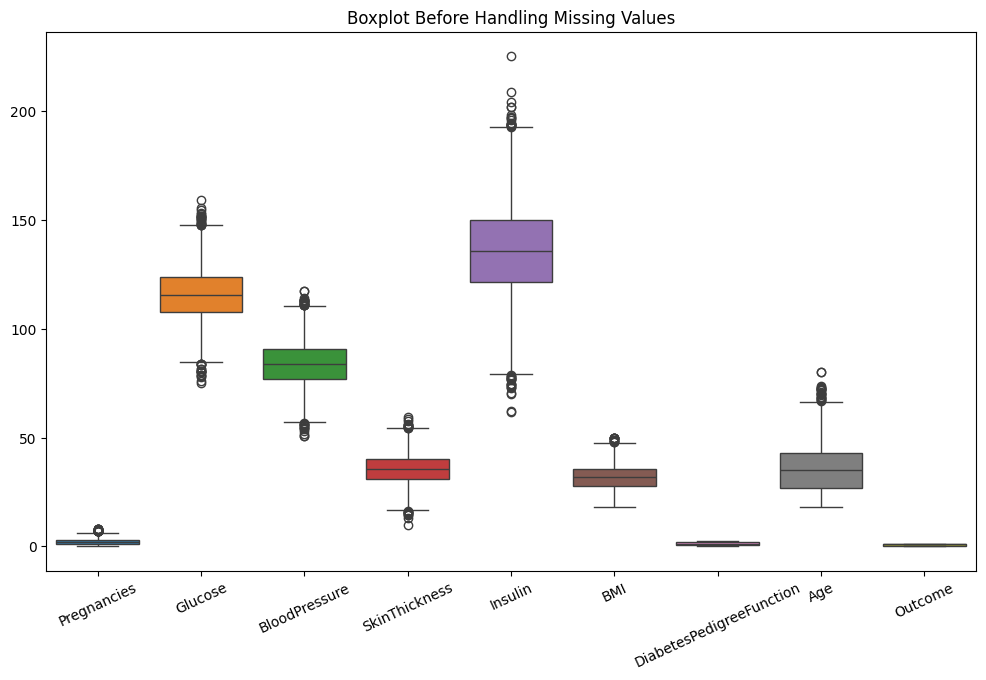

In [7]:
# Boxplot before handling missing values
plt.figure(figsize=(12,7))
sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.title("Boxplot Before Handling Missing Values")
plt.xticks(rotation=25)
plt.show()

In [8]:
df["Glucose"] = df["Glucose"].fillna(df["Glucose"].mean())
df["BloodPressure"] = df["BloodPressure"].fillna(df["BloodPressure"].mean())
df["SkinThickness"] = df["SkinThickness"].fillna(df["SkinThickness"].mean())
df["Insulin"] = df["Insulin"].fillna(df["Insulin"].mean())
df["BMI"] = df["BMI"].fillna(df["BMI"].mean())

In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
BMI_Category                0
Age_Group                   0
Glucose_Level               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['BMI_Category'] = df['BMI_Category'].map({
    'Underweight': 0,
    'Normal': 1,
    'Overweight': 2,
    'Obese': 3,
    'Missing': -1
})

df['Age_Group'] = df['Age_Group'].map({
    'Young': 0,
    'Adult': 1,
    'Mid': 2,
    'Pre-Senior': 3,
    'Senior': 4,
    'Missing': -1
})

df['Glucose_Level'] = df['Glucose_Level'].map({
    'Normal': 0,
    'Prediabetes': 1,
    'Diabetes': 2,
    'Missing': -1
})

In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Level
0,1,123.854532,70.552013,47.564623,140.225349,44.067900,0.205703,40.960570,0,3,2,1
1,1,117.297774,71.079050,41.263556,111.154260,29.703077,1.136390,33.340828,0,2,1,1
2,2,110.176908,100.378619,29.175547,117.197124,28.162753,1.915921,42.772262,0,2,2,1
3,2,116.422941,95.603386,32.177355,143.376177,31.713198,2.046737,53.276358,1,3,2,1
4,4,97.760847,77.837421,33.367973,121.180076,29.708066,0.585468,32.190160,1,2,1,0


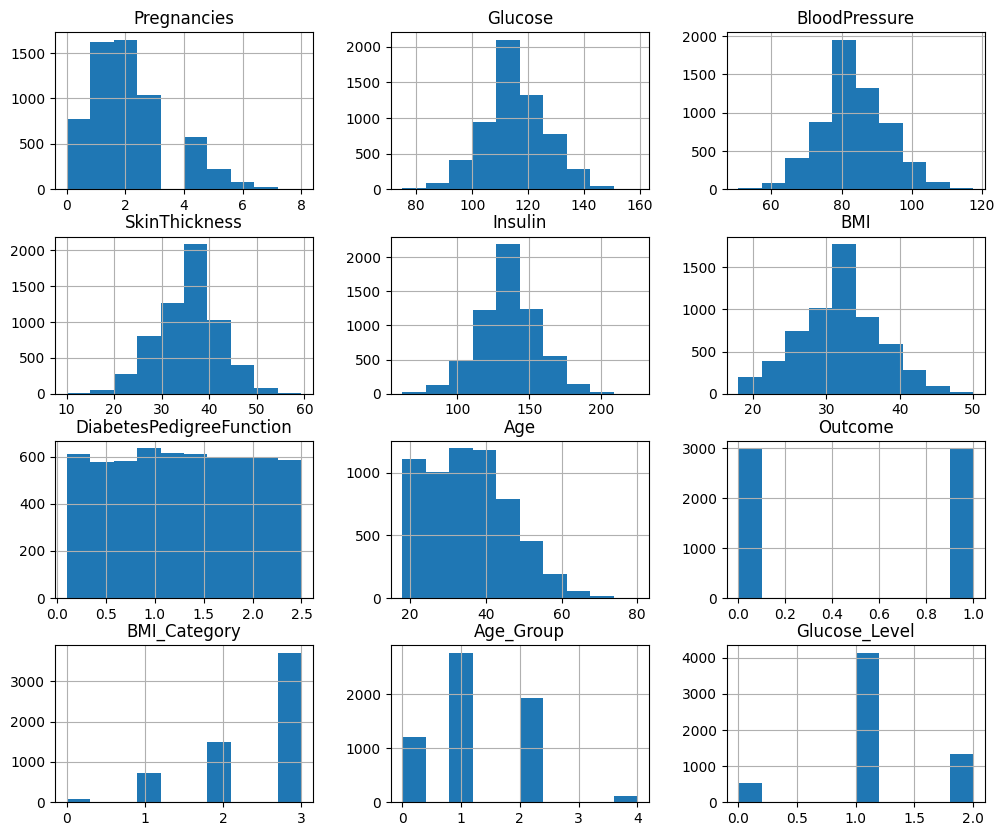

In [13]:
df.hist(figsize=(12,10))
plt.show()

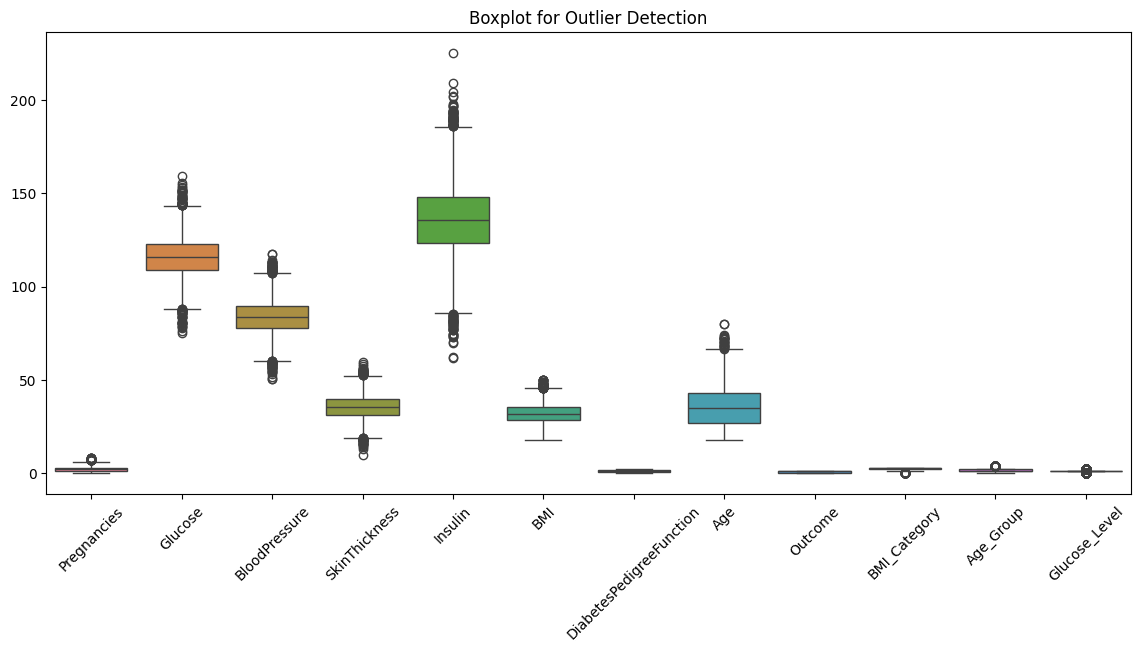

In [14]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

In [15]:
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","Age"]

for col in cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_limit, lower_limit, df[col])
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

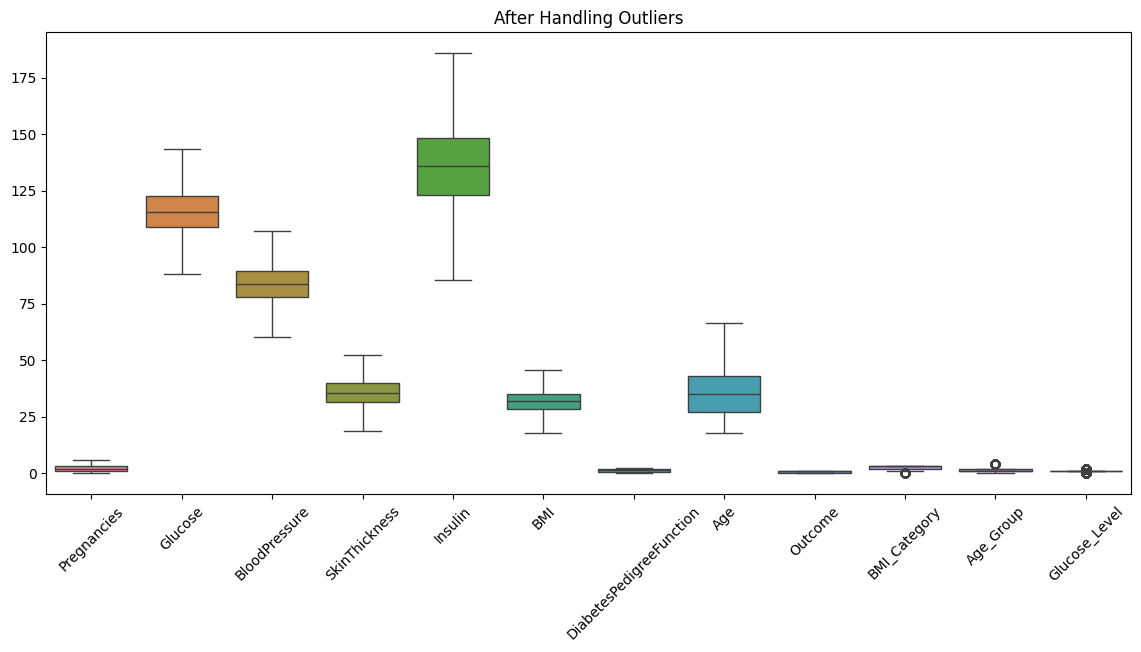

In [16]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.title("After Handling Outliers")
plt.xticks(rotation=45)
plt.show()

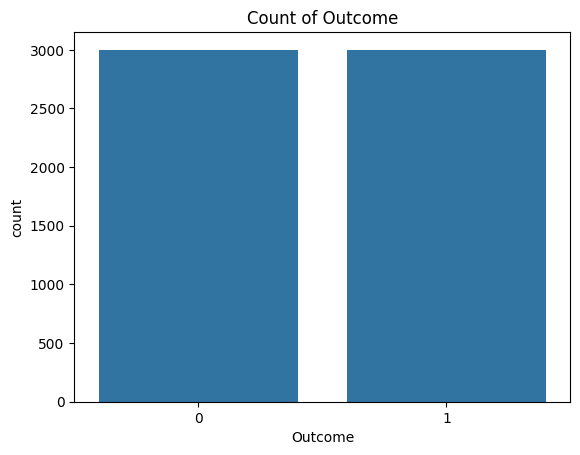

In [17]:
sns.countplot(x="Outcome", data=df)
plt.title("Count of Outcome")
plt.show()

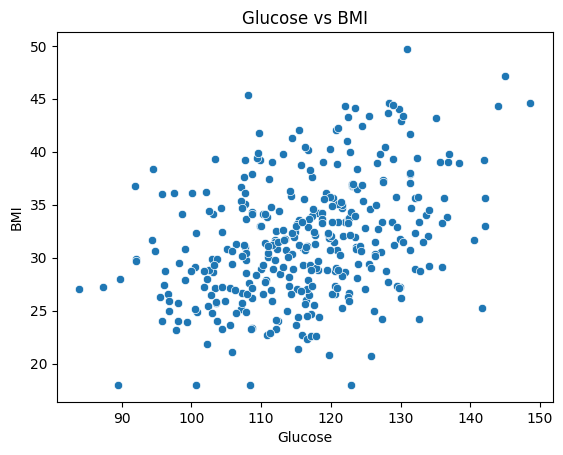

In [11]:
sns.scatterplot(x="Glucose", y="BMI", data=df.sample(400))
plt.title("Glucose vs BMI")
plt.show()

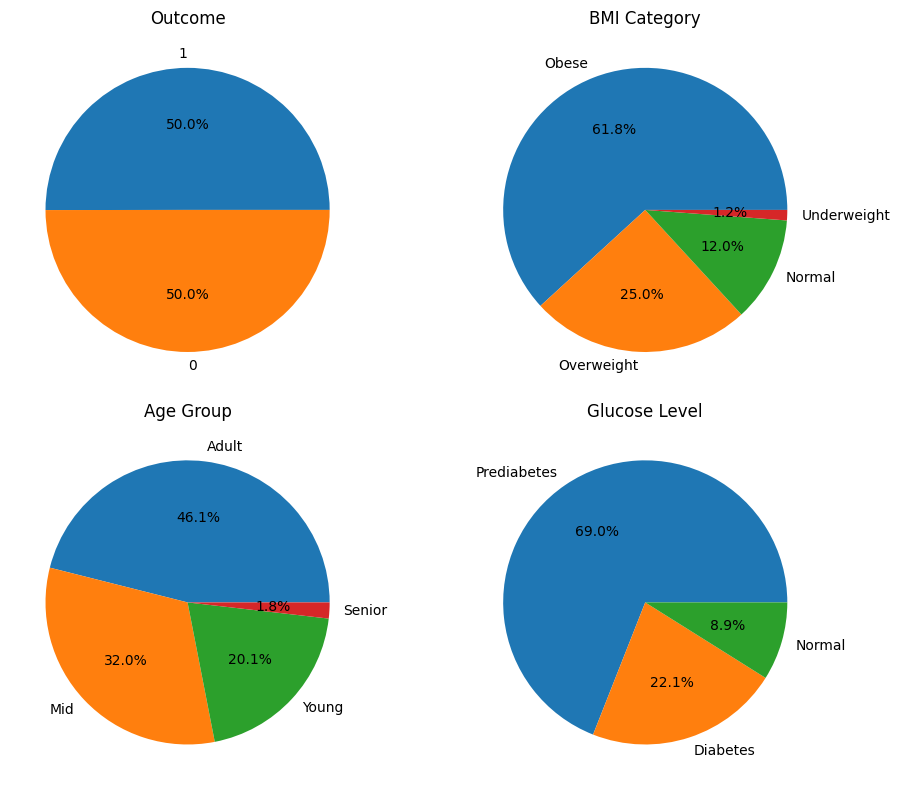

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
df['Outcome'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Outcome')
plt.ylabel('')

plt.subplot(2,2,2)
df['BMI_Category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('BMI Category')
plt.ylabel('')

plt.subplot(2,2,3)
df['Age_Group'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Age Group')
plt.ylabel('')

plt.subplot(2,2,4)
df['Glucose_Level'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Glucose Level')
plt.ylabel('')

plt.tight_layout()
plt.show()

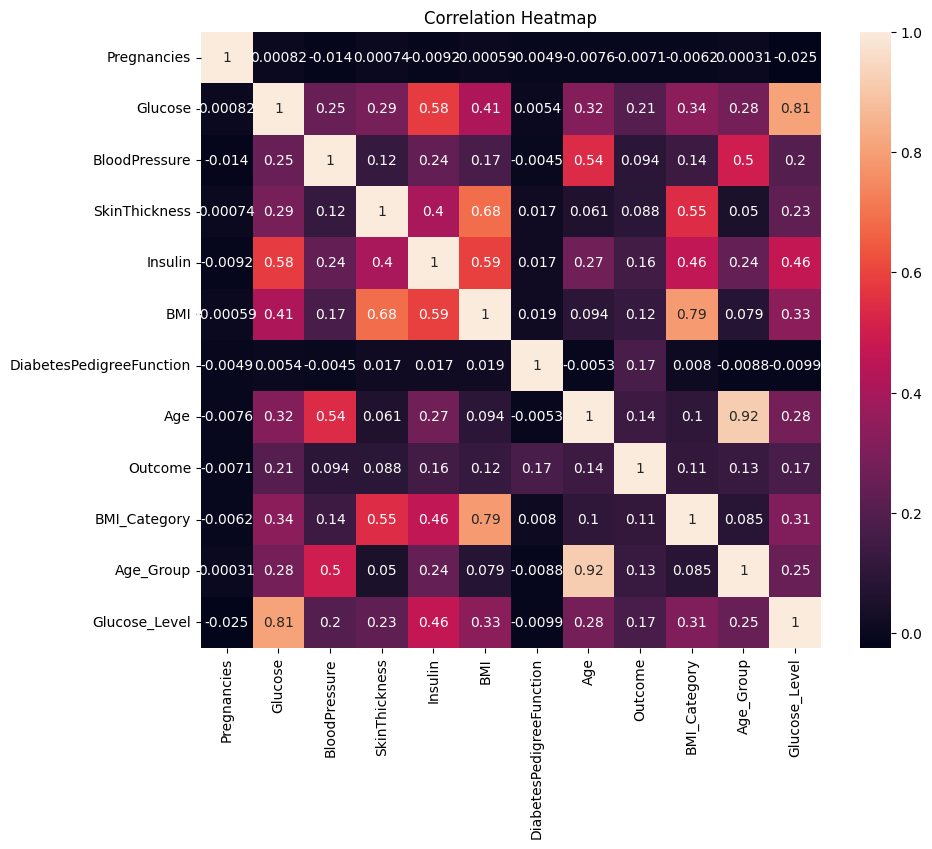

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

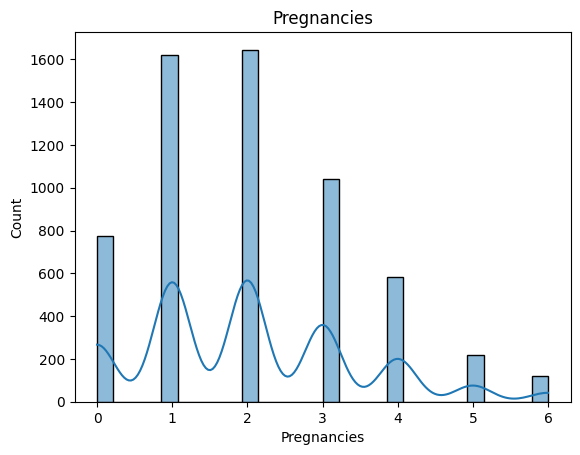

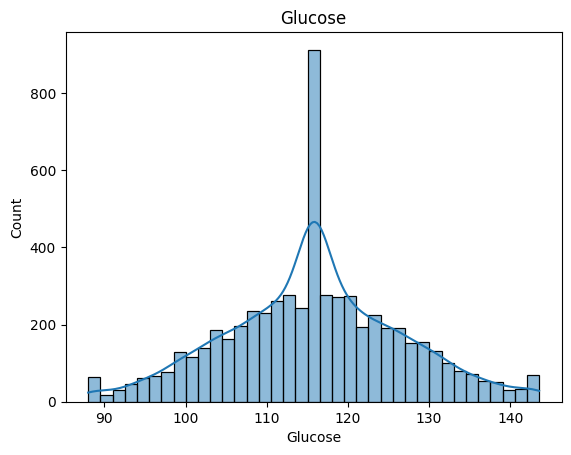

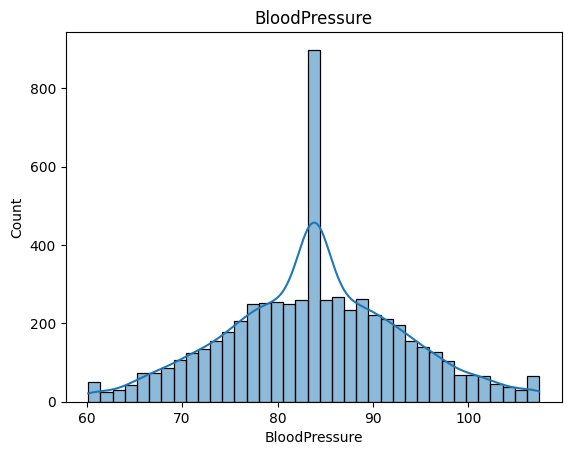

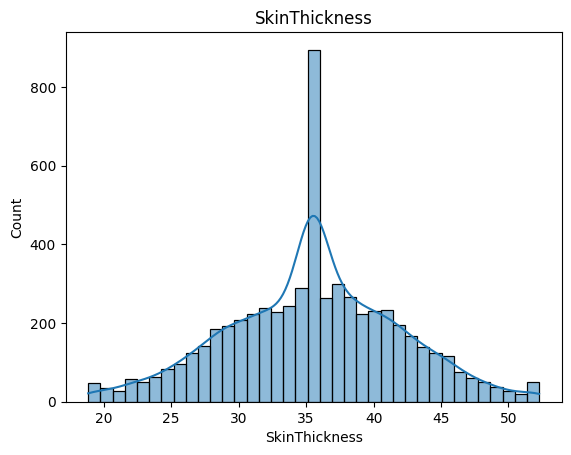

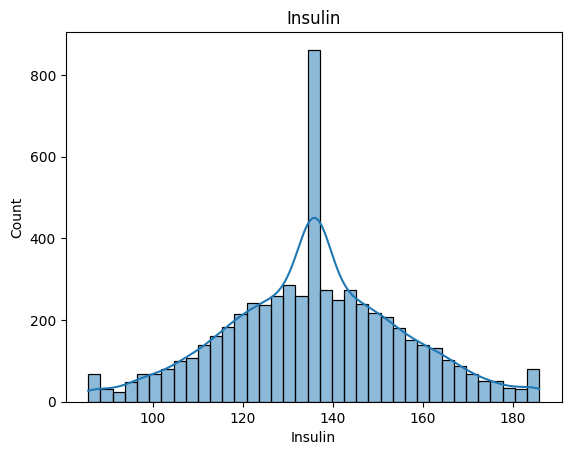

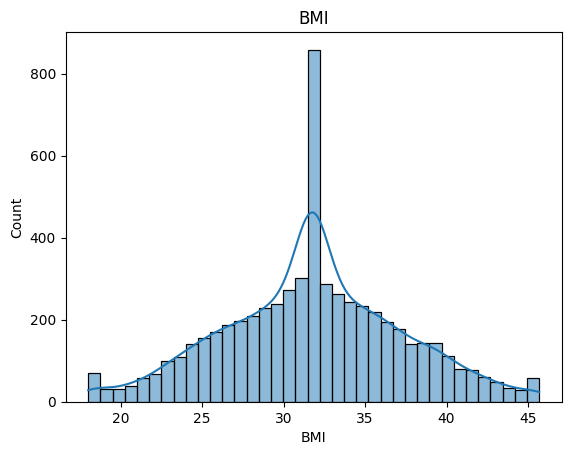

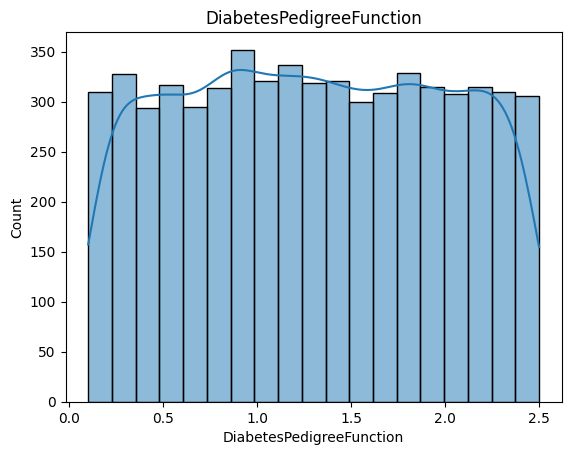

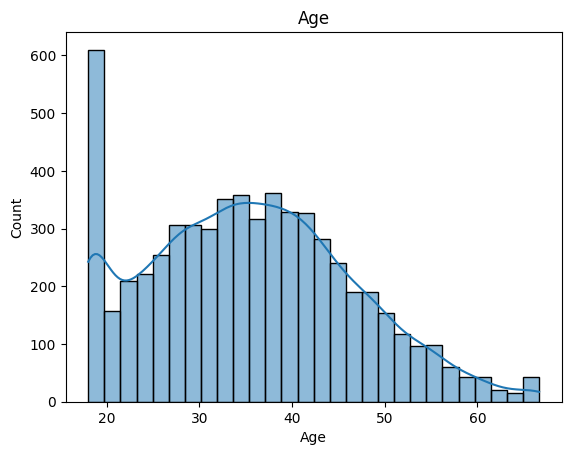

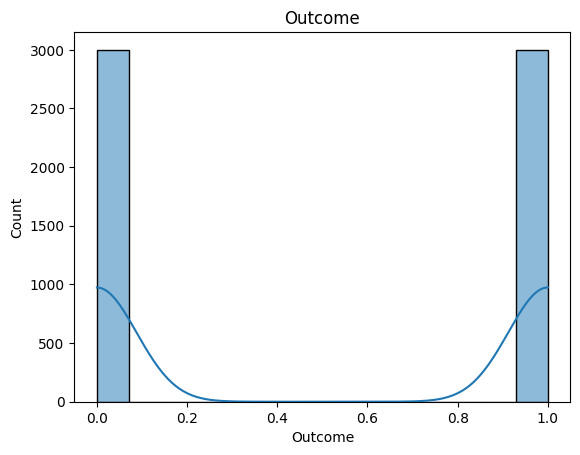

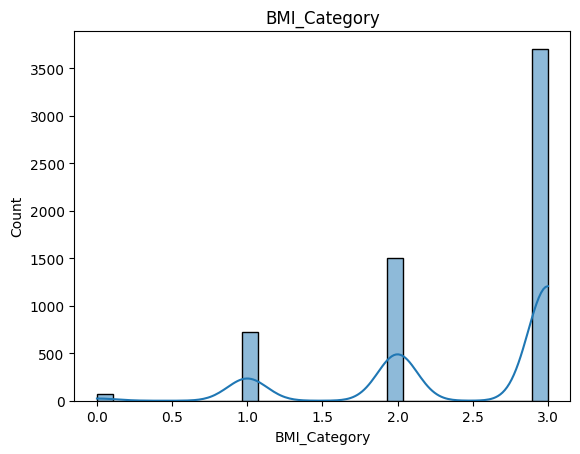

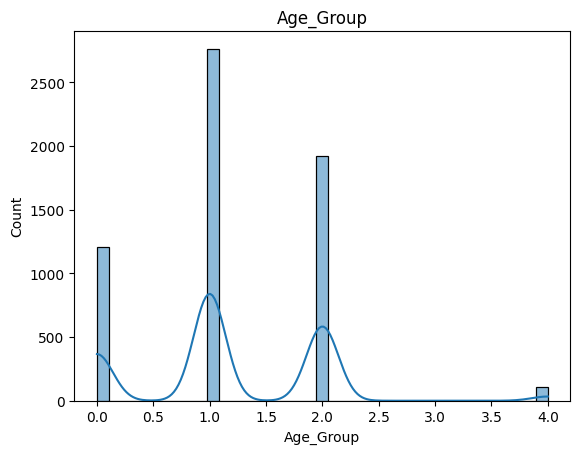

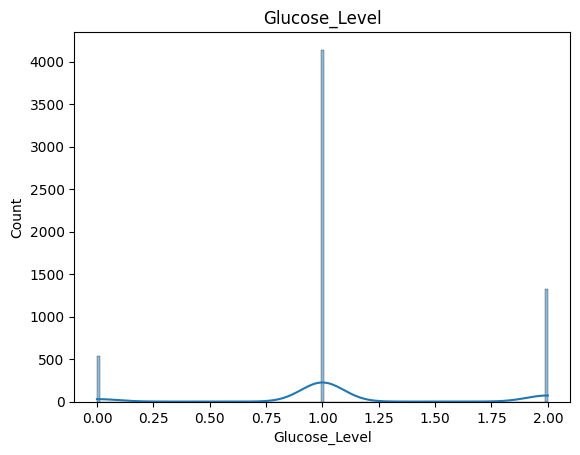

In [19]:
# Distribution
for col in df.columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

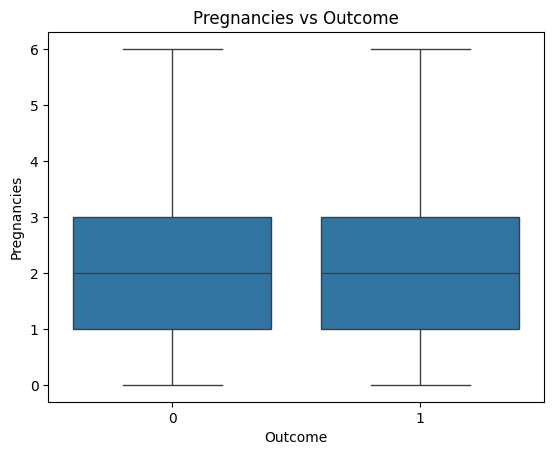

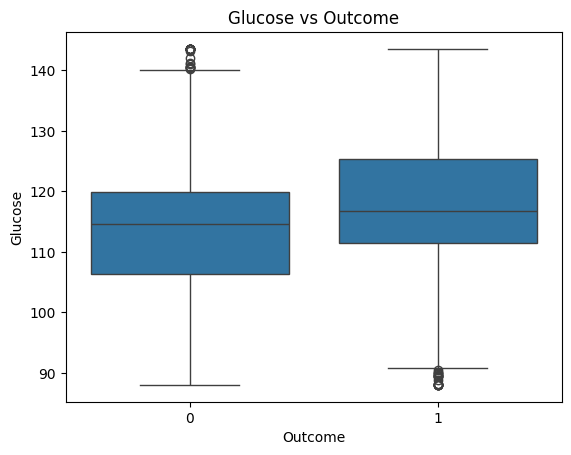

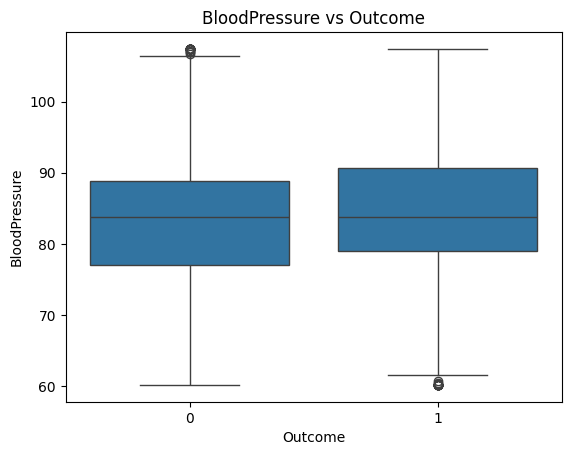

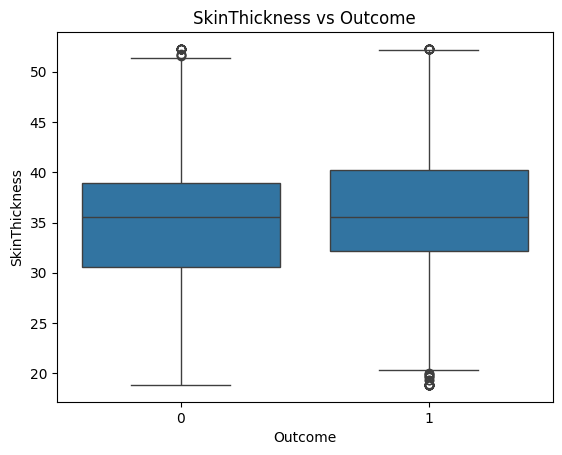

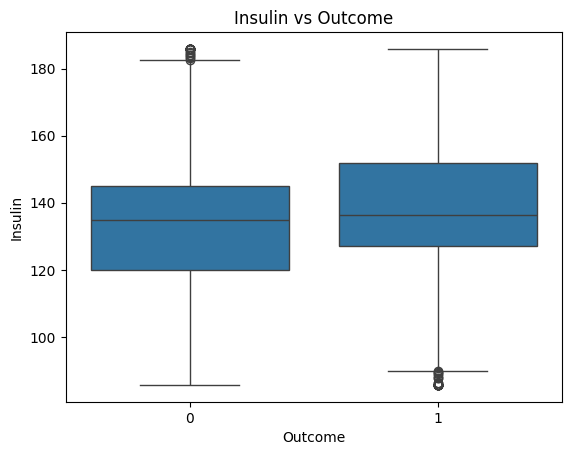

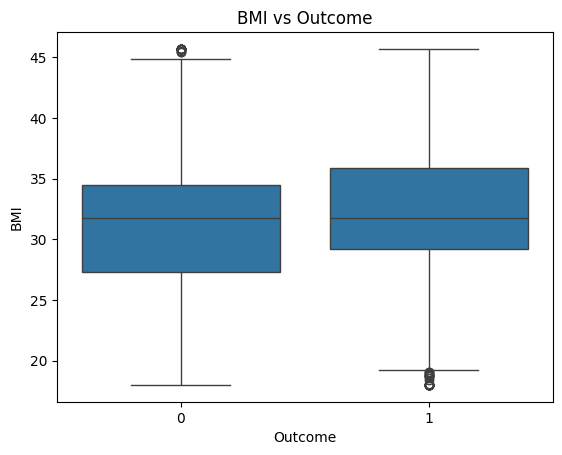

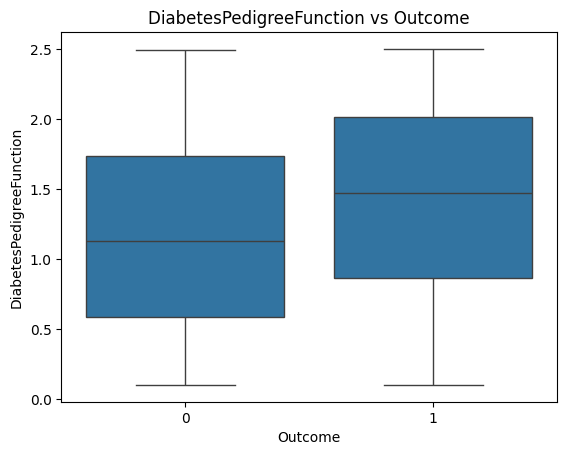

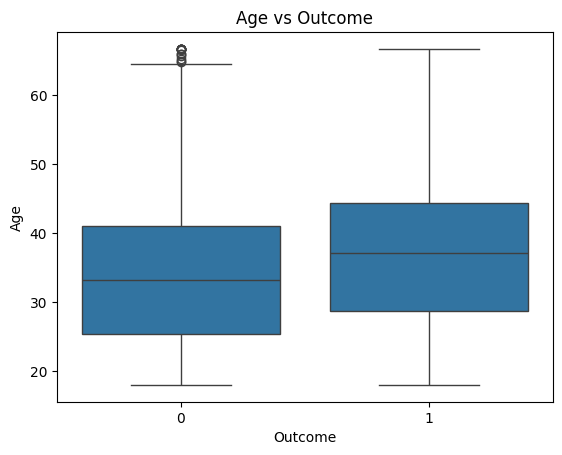

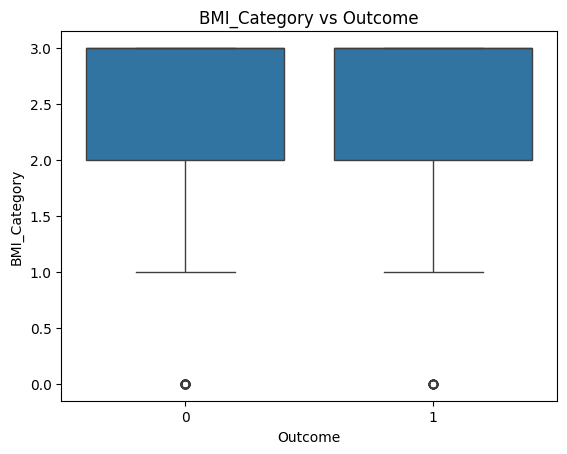

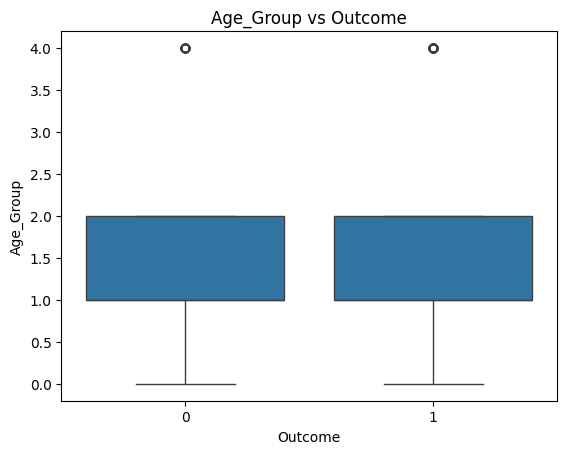

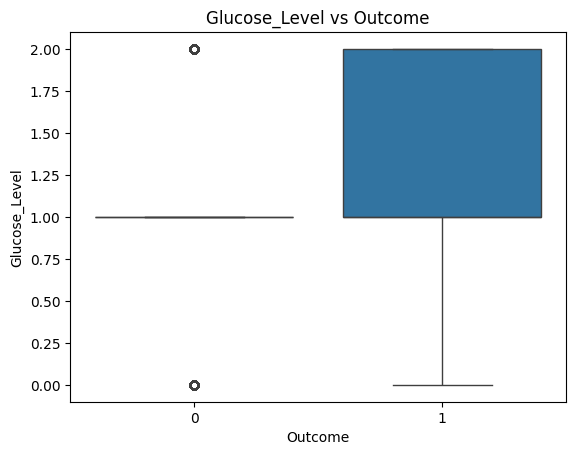

In [20]:
# Feature vs Target
for col in df.columns:
    if col != "Outcome":
        plt.figure()
        sns.boxplot(x="Outcome", y=col, data=df)
        plt.title(f"{col} vs Outcome")
        plt.show()

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import notebook

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Jupyter Notebook:", notebook.__version__)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
Pandas: 3.0.1
NumPy: 2.4.3
Matplotlib: 3.10.8
Seaborn: 0.13.2
Jupyter Notebook: 7.5.4
